In [1]:
print ('Hello')

Hello


In [2]:
import sympy as sp

# Definisikan variabel simbolik
k, C_methanol, C_oil = sp.symbols('k C_methanol C_oil')

# Persamaan kinetika reaksi transesterifikasi sederhana
yield_reaksi = k * C_methanol * C_oil

# Tampilkan persamaan
yield_reaksi

C_methanol*C_oil*k

In [3]:
nilai_yield = yield_reaksi.subs({k: 0.5, C_methanol: 2.0, C_oil: 1.0})
print("Yield biodiesel =", nilai_yield, "kg")

Yield biodiesel = 1.00000000000000 kg


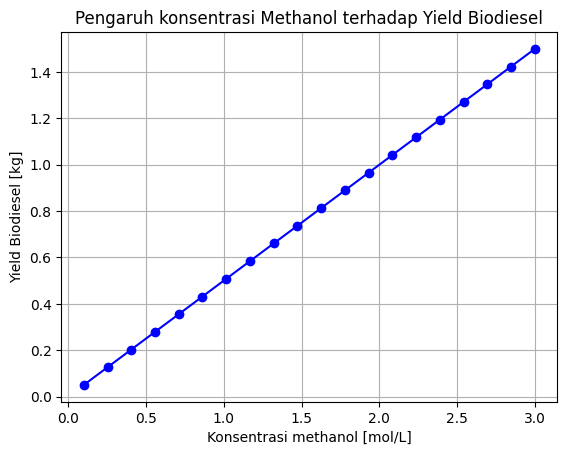

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Tetapkan nilai k dan C_oil tetap
k_val = 0.5
C_oil_val = 1.0

# Buat range konsentrasi methanol dari 0.1 sampai 3.0
C_methanol_range = np.linspace(0.1, 3.0, 20)

# Hitung yield untuk setiap nilai methano; pakai sympy
yield_list = []
for C_m in C_methanol_range:
    yield_i = yield_reaksi.subs({k: k_val, C_methanol: C_m, C_oil: C_oil_val})
    yield_list.append(float(yield_i)) # Ubah ke float biar bisa di plot

# Plot grafiknya
plt.plot(C_methanol_range, yield_list, marker='o', color='blue')
plt.xlabel('Konsentrasi methanol [mol/L]')
plt.ylabel('Yield Biodiesel [kg]')
plt.title('Pengaruh konsentrasi Methanol terhadap Yield Biodiesel')
plt.grid(True)
plt.savefig('Porto_Biodiesel_Yield_vs_Methanol_1.png', dpi=300, bbox_inches='tight') # Simpan PNG
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

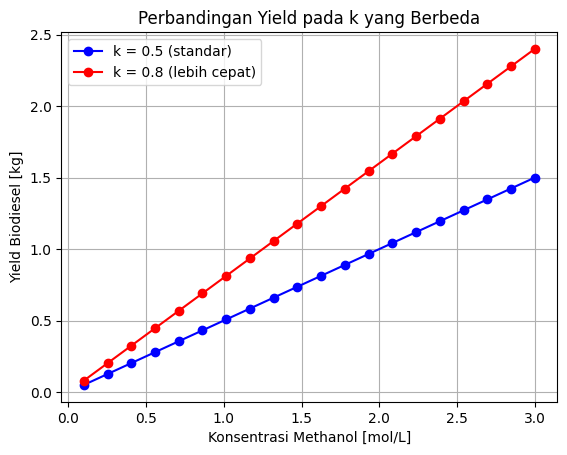

In [5]:
import matplotlib.pyplot as plt
import numpy as np

C_oil_val = 1.0
C_methanol_range = np.linspace(0.1, 3.0, 20)

# Bikin 2 garis: k=0.5 dan k=0.8 buat dibandingkan
k_values = [0.5, 0.8]
warna =['blue', 'red']
label = ['k = 0.5 (standar)', 'k = 0.8 (lebih cepat)']
for i, k_val in enumerate(k_values):
    yield_list =[]
    for C_m in C_methanol_range:
        yield_i = yield_reaksi.subs({k: k_val, C_methanol: C_m, C_oil: C_oil_val})
        yield_list.append(float(yield_i))
    plt.plot(C_methanol_range, yield_list, marker='o', color=warna[i],label=label[i])

plt.xlabel('Konsentrasi Methanol [mol/L]')
plt.ylabel('Yield Biodiesel [kg]')
plt.title('Perbandingan Yield pada k yang Berbeda')
plt.legend() # biar ada keterangan warna
plt.grid(True)
plt.savefig('Porto_Biodiesel_Yield_vs_Methanol_2.png', dpi=300, bbox_inches='tight') # Simpan PNG
plt.show

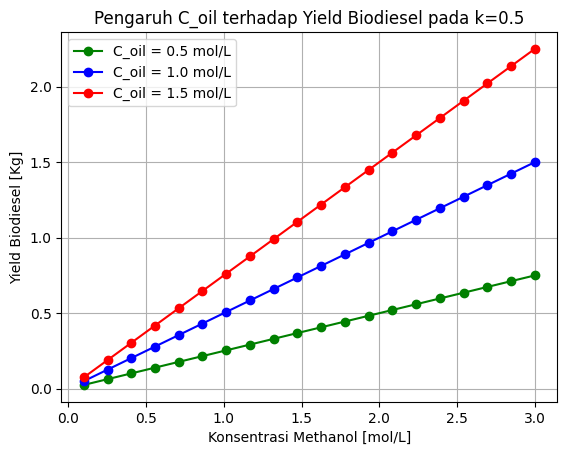

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import sympy as sp

# 1. Bikin variabel simbolik
k, C_methanol, C_oil = sp.symbols('k C_methanol C_oil')
yield_reaksi = k * C_methanol * C_oil

# 2. Set nilai tetap untuk k
k_val = 0.5

# 3. Bikin range methanol dari 0.1 sampai 3.0, ada 20 titik
C_methanol_range = np.linspace(0.1, 3.0, 20)

# 4. Bikin 3 nilai C_oil yang mau dibandingkan 
C_oil_values = [0.5, 1.0, 1.5]
warna = ['green', 'blue', 'red']
label = ['C_oil = 0.5 mol/L', 'C_oil = 1.0 mol/L', 'C_oil = 1.5 mol/L']

# 5. Looping buat 3 baris
for i, C_oil_val in enumerate(C_oil_values):
    yield_list = [] # list kosong buat nyimpen hasil per C_oil
    for C_m in C_methanol_range:
        yield_i = yield_reaksi.subs({k: k_val, C_methanol: C_m, C_oil: C_oil_val})
        yield_list.append(float(yield_i)) # konversi ke float biar bisa diplot
    plt.plot(C_methanol_range, yield_list, marker='o', color=warna[i], label=label[i])

# 6. Bikin tampilan grafik
plt.xlabel('Konsentrasi Methanol [mol/L]')
plt.ylabel('Yield Biodiesel [Kg]')
plt.title('Pengaruh C_oil terhadap Yield Biodiesel pada k=0.5')
plt.legend() # munculin keterangan 3 warna
plt.grid(True)
plt.savefig('Porto_Biodiesel_Yield_vs_Methanol_3.png', dpi=300, bbox_inches='tight') # Simpan PNG
plt.show()

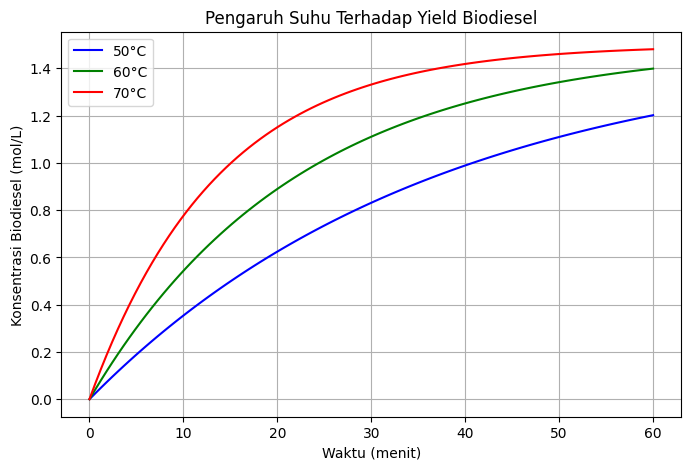

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
# 1. FUNGSI ARRHENIUS - HUTUNG K BERDASARKAN SUHU
def hitung_k(T_celcius):
    T = T_celcius + 273.5 # Ubah Celcius ke Kelvin
    A = 1.2e5 # Faktor frekuensi
    Ea = 45000 # Energi aktivasi J/mol
    R = 8.134 # Konstanta gas ideal
    k = A * np.exp(-Ea / (R * T))
    return k

# 2. FUNGSI MODEL REAKSI
def model(C, t, k, C_methanol):
    C_oil, C_biodiesel = C
    dC_oil_dt = -k * C_oil * C_methanol
    dC_biodiesel_dt = k * C_oil * C_methanol
    return [dC_oil_dt, dC_biodiesel_dt]

# 3. PARAMETER SIMULASI
C_oil_awal = 1.5 # KOnsentrasi minyak awal mol/L
C_methanol = 6.0 # KOnsentrasi methanol awal mol/L
t_max = 60 # Waktu Simulasi Menit
t = np.linspace(0, t_max, 100)
C0 = [C_oil_awal, 0] # Kondisi awal minyak 1.5, biodiesel 0

# 4. SIMULASI 3 SUHU BEBEDA
suhu_list = [50, 60, 70] # 3 suhu yang mau dibandingkan
warna_list = ['blue', 'green', 'red']
label_list = ['50\u00b0C', '60\u00b0C', '70\u00b0C']

plt.figure(figsize=(8,5))

for i, T in enumerate(suhu_list):
    k = hitung_k(T) # Hitung k untuk suhu ini
    solution = odeint(model, C0, t, args=(k, C_methanol))
    C_biodiesel = solution[:, 1] #Ambil hasil biodiesel
    plt.plot(t, C_biodiesel, color=warna_list[i], label=label_list[i])

# 5.PLOT GRAFIK
plt.xlabel('Waktu (menit)')
plt.ylabel('Konsentrasi Biodiesel (mol/L)')
plt.title('Pengaruh Suhu Terhadap Yield Biodiesel')
plt.legend()
plt.grid(True)
plt.savefig('Porto_Biodiesel_Yield_vs_Methanol_4.png', dpi=300, bbox_inches='tight') # Simpan PNG
plt.show()